# 3 — Análise Exploratória (EDA)

**Pré-requisito:** `data/processed/dataset.csv` gerado pelo notebook 2.

**Saídas:** `figures/benchmark_backtracking.png`, `figures/class_distribution.png`, `figures/correlation_matrix.png`, `figures/mutual_info.png`

In [6]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings('ignore')

RANDOM_STATE  = 42
ROOT_DIR      = Path('.')
DATASET_PATH  = ROOT_DIR / 'data' / 'processed' / 'dataset.csv'
FIGURES_DIR   = ROOT_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_COLS = [
    'n_vertices', 'n_edges', 'density',
    'min_degree', 'max_degree', 'mean_degree', 'std_degree',
    'avg_clustering', 'diameter', 'is_disconnected',
    'avg_betweenness', 'largest_clique', 'n_components',
]

FEATURE_LABELS = {
    'n_vertices'     : 'Nº Vértices',
    'n_edges'        : 'Nº Arestas',
    'density'        : 'Densidade',
    'min_degree'     : 'Grau Mínimo',
    'max_degree'     : 'Grau Máximo',
    'mean_degree'    : 'Grau Médio',
    'std_degree'     : 'Desvio Grau',
    'avg_clustering' : 'Coef. Agrupamento',
    'diameter'       : 'Diâmetro',
    'is_disconnected': 'Desconexo',
    'avg_betweenness': 'Betweenness Médio',
    'largest_clique' : 'Maior Clique',
    'n_components'   : 'Nº Componentes',
}

df = pd.read_csv(DATASET_PATH)
print(f'Dataset carregado: {len(df)} instâncias, {df["chi"].nunique()} classes')

Dataset carregado: 630 instâncias, 30 classes


## Distribuição das Classes

## Benchmark do Backtracking — Limite de Escalabilidade

Mostra a partir de quantos nós/densidade o algoritmo exato começa a falhar, motivando a abordagem preditiva.

In [7]:
if 'chi_timed_out' not in df.columns:
    print("AVISO: dataset.csv não possui as colunas 'chi_time' e 'chi_timed_out'.")
    print("Delete data/processed/dataset.csv e re-execute o notebook 2 para gerar o benchmark.")
else:
    TIMEOUT_SEC = 60  # deve ser o mesmo valor usado na extração

    solved   = df[df['chi_timed_out'] == 0].copy()
    timedout = df[df['chi_timed_out'] == 1].copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Nós × Tempo ───────────────────────────────────────────────────────────
    ax = axes[0]
    ax.scatter(solved['n_vertices'],   solved['chi_time'],
               c='steelblue', alpha=0.4, s=18, label='Resolvido', zorder=2)
    ax.scatter(timedout['n_vertices'], timedout['chi_time'],
               c='crimson',  alpha=0.8, s=30, marker='x', label='Timeout', zorder=3)
    ax.axhline(TIMEOUT_SEC, color='crimson', linestyle='--', linewidth=1.2,
               label=f'Limite ({TIMEOUT_SEC}s)')
    ax.set_xlabel('Nº de Vértices')
    ax.set_ylabel('Tempo de execução (s)')
    ax.set_title('Backtracking: Nós × Tempo')
    ax.legend(fontsize=9)
    ax.set_yscale('log')

    # ── Densidade × Tempo ─────────────────────────────────────────────────────
    ax = axes[1]
    ax.scatter(solved['density'],   solved['chi_time'],
               c='steelblue', alpha=0.4, s=18, label='Resolvido', zorder=2)
    ax.scatter(timedout['density'], timedout['chi_time'],
               c='crimson',  alpha=0.8, s=30, marker='x', label='Timeout', zorder=3)
    ax.axhline(TIMEOUT_SEC, color='crimson', linestyle='--', linewidth=1.2,
               label=f'Limite ({TIMEOUT_SEC}s)')
    ax.set_xlabel('Densidade')
    ax.set_ylabel('Tempo de execução (s)')
    ax.set_title('Backtracking: Densidade × Tempo')
    ax.legend(fontsize=9)
    ax.set_yscale('log')

    plt.suptitle('Limite de Escalabilidade do Backtracking Exato', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'benchmark_backtracking.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Resolvidos : {len(solved):4d} ({100*len(solved)/len(df):.1f}%)')
    print(f'Timeout    : {len(timedout):4d} ({100*len(timedout)/len(df):.1f}%)')
    if len(timedout) > 0:
        print(f'\nGrafos com timeout por tipo:')
        print(timedout['graph_type'].value_counts().to_string())

AVISO: dataset.csv não possui as colunas 'chi_time' e 'chi_timed_out'.
Delete data/processed/dataset.csv e re-execute o notebook 2 para gerar o benchmark.


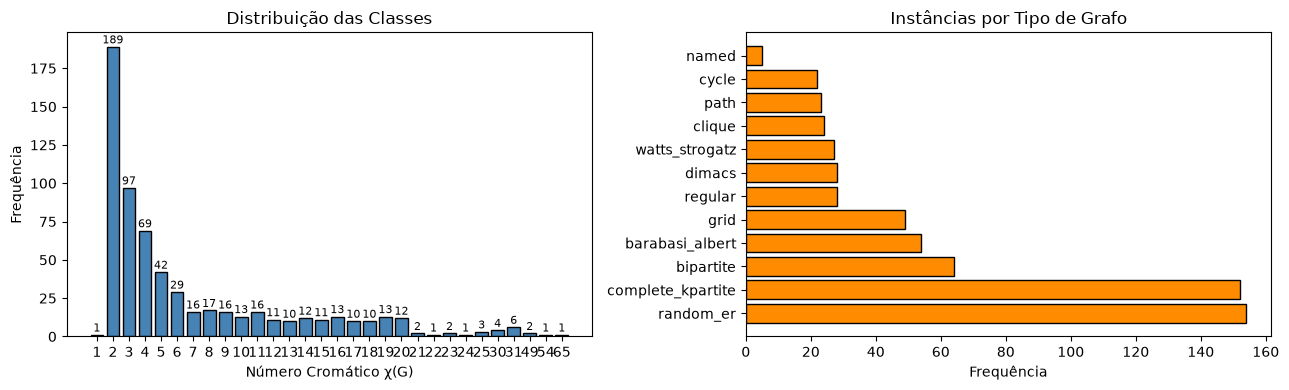

Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(30), np.int64(31), np.int64(49), np.int64(54), np.int64(65)]

Instâncias por classe:
 chi
1       1
2     189
3      97
4      69
5      42
6      29
7      16
8      17
9      16
10     13
11     16
12     11
13     10
14     12
15     11
16     13
17     10
18     10
19     13
20     12
21      2
22      1
23      2
24      1
25      3
30      4
31      6
49      2
54      1
65      1


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

chi_counts = df['chi'].value_counts().sort_index()
axes[0].bar(chi_counts.index.astype(str), chi_counts.values,
            color='steelblue', edgecolor='black')
axes[0].set_xlabel('Número Cromático χ(G)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição das Classes')
for i, (xi, v) in enumerate(zip(chi_counts.index, chi_counts.values)):
    axes[0].text(i, v + 0.5, str(v), ha='center', va='bottom', fontsize=8)

type_counts = df['graph_type'].value_counts()
axes[1].barh(type_counts.index, type_counts.values,
             color='darkorange', edgecolor='black')
axes[1].set_xlabel('Frequência')
axes[1].set_title('Instâncias por Tipo de Grafo')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Classes:', sorted(df['chi'].unique()))
print('\nInstâncias por classe:\n', chi_counts.to_string())

## Matriz de Correlação

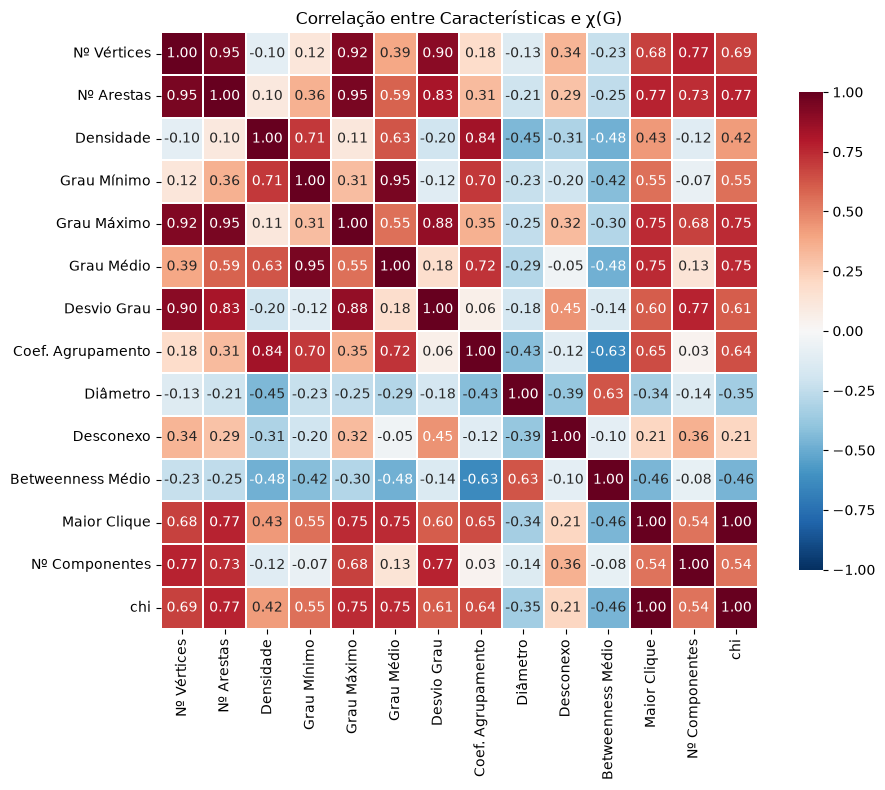

In [9]:
corr_cols = FEATURE_COLS + ['chi']
corr      = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    xticklabels=[FEATURE_LABELS.get(c, c) for c in corr_cols],
    yticklabels=[FEATURE_LABELS.get(c, c) for c in corr_cols],
    ax=ax, linewidths=0.3, square=True, cbar_kws={'shrink': 0.8},
)
ax.set_title('Correlação entre Características e χ(G)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Informação Mútua

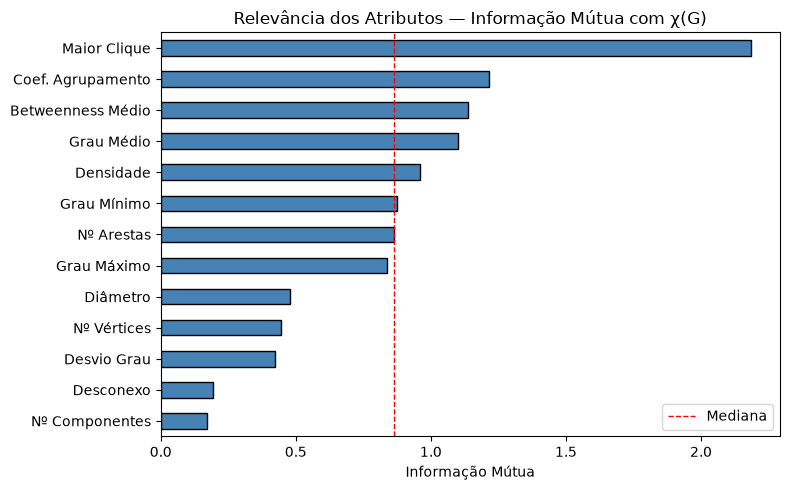

Ranking (desc.):
  Maior Clique              2.1834
  Coef. Agrupamento         1.2154
  Betweenness Médio         1.1364
  Grau Médio                1.1022
  Densidade                 0.9606
  Grau Mínimo               0.8762
  Nº Arestas                0.8629
  Grau Máximo               0.8358
  Diâmetro                  0.4783
  Nº Vértices               0.4469
  Desvio Grau               0.4248
  Desconexo                 0.1947
  Nº Componentes            0.1700


In [10]:
X_all = df[FEATURE_COLS].values.astype(float)
y_all = df['chi'].values.astype(int)

mi_vals = mutual_info_classif(X_all, y_all, random_state=RANDOM_STATE)
mi_df   = pd.Series(mi_vals, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
mi_df.rename(index=FEATURE_LABELS).plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='black'
)
ax.axvline(mi_df.median(), color='red', linestyle='--', linewidth=1, label='Mediana')
ax.set_xlabel('Informação Mútua')
ax.set_title('Relevância dos Atributos — Informação Mútua com χ(G)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'mutual_info.png', dpi=150, bbox_inches='tight')
plt.show()

print('Ranking (desc.):')
for feat, val in mi_df.sort_values(ascending=False).items():
    print(f'  {FEATURE_LABELS[feat]:<25} {val:.4f}')